In [2]:
import pandas as pd

# Load CSV file
df = pd.read_csv("Telco-Customer-Churn.csv")

# Count Churn Yes and No
churn_count = df["Churn"].value_counts()

print("Customers with Churn = Yes:", churn_count.get("Yes", 0))
print("Customers with Churn = No:", churn_count.get("No", 0))

Customers with Churn = Yes: 8
Customers with Churn = No: 12


In [3]:
# Q2: Contract type vs Churn

contract_churn = pd.crosstab(df["Contract"], df["Churn"])

print("\nContract Type vs Churn:")
print(contract_churn)

print("\nChurned Customers by Contract Type:")
print(contract_churn["Yes"])



Contract Type vs Churn:
Churn           No  Yes
Contract               
Month-to-month   3    7
One year         4    1
Two year         5    0

Churned Customers by Contract Type:
Contract
Month-to-month    7
One year          1
Two year          0
Name: Yes, dtype: int64


In [4]:
# Q3: Average MonthlyCharges for churned and non-churned customers

churned_avg = df.loc[df["Churn"] == "Yes", "MonthlyCharges"].mean()
not_churned_avg = df.loc[df["Churn"] == "No", "MonthlyCharges"].mean()

print("\nAverage MonthlyCharges:")
print("Churned customers (Yes):", round(churned_avg, 2))
print("Non-churned customers (No):", round(not_churned_avg, 2))


Average MonthlyCharges:
Churned customers (Yes): 82.6
Non-churned customers (No): 43.09



Internet Service vs Churn:
Churn            No  Yes
InternetService         
DSL               6    2
Fiber optic       0    6
No                6    0


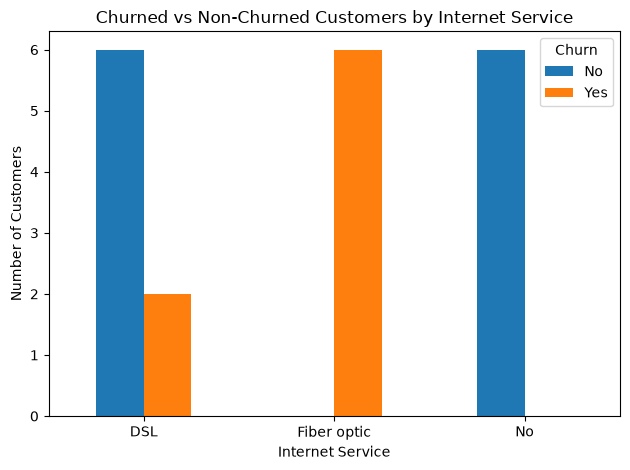

In [5]:
# Q4: Churn by InternetService

internet_churn = pd.crosstab(df["InternetService"], df["Churn"])

print("\nInternet Service vs Churn:")
print(internet_churn)

# Create bar chart
internet_churn.plot(kind="bar")

import matplotlib.pyplot as plt

plt.title("Churned vs Non-Churned Customers by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

In [6]:
# Q5: Correlation between Tenure and Churn

# Convert Churn: Yes = 1, No = 0
df["ChurnNumeric"] = df["Churn"].map({"Yes": 1, "No": 0})

# Calculate correlation
correlation = df["Tenure"].corr(df["ChurnNumeric"])

print("\nCorrelation between Tenure and Churn:", round(correlation, 3))

# Interpretation
if correlation < 0:
    print("Interpretation: There is a negative correlation.")
    print("Customers with higher tenure tend to churn less.")
elif correlation > 0:
    print("Interpretation: There is a positive correlation.")
    print("Customers with higher tenure tend to churn more.")
else:
    print("Interpretation: There is no correlation.")


Correlation between Tenure and Churn: -0.766
Interpretation: There is a negative correlation.
Customers with higher tenure tend to churn less.
